# **Step 1 — Imports and setup**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# **Step 2 — Find and load the dataset**

In [7]:
import os
csv_paths = ['diabetes.csv']
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.lower().endswith('.csv'):
            csv_paths.append(os.path.join(dirname, filename))
print("CSV files found:", csv_paths)

data_path = csv_paths[0]
df = pd.read_csv(data_path)
print(df.shape)
df.head()

CSV files found: ['diabetes.csv']
(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Step 3 — First look at the data**

In [8]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# **Step 4 — Target distribution**

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


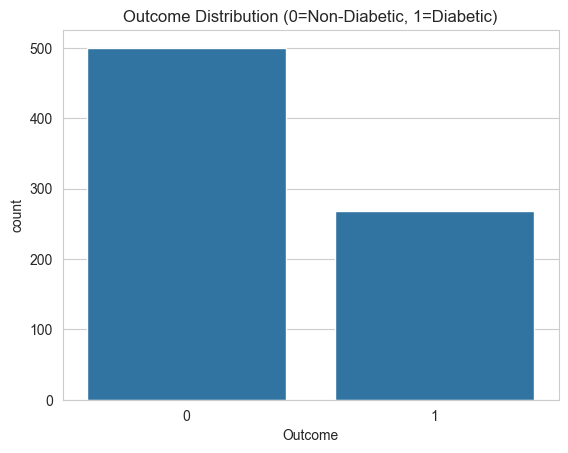

In [9]:
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True))

sns.countplot(x='Outcome', data=df)
plt.title('Outcome Distribution (0=Non-Diabetic, 1=Diabetic)')
plt.show()

# **Step 5 — Check for disguised missing values (zeros)**

In [10]:
cols_zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[cols_zero_invalid] == 0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


# **Step 6 — EDA plots**

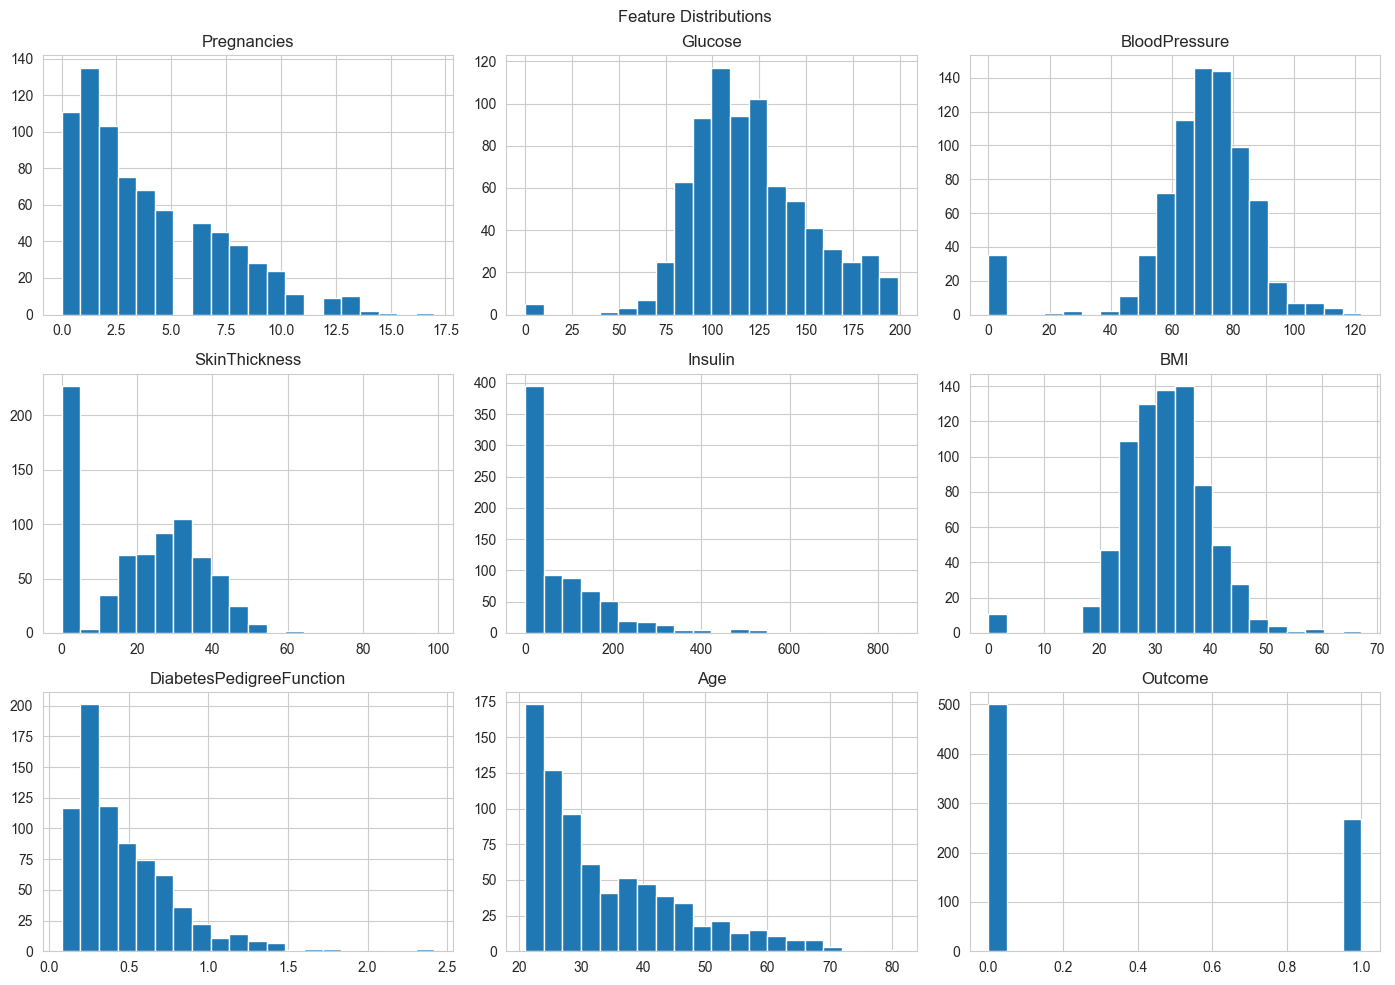

In [11]:
df.hist(figsize=(14, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

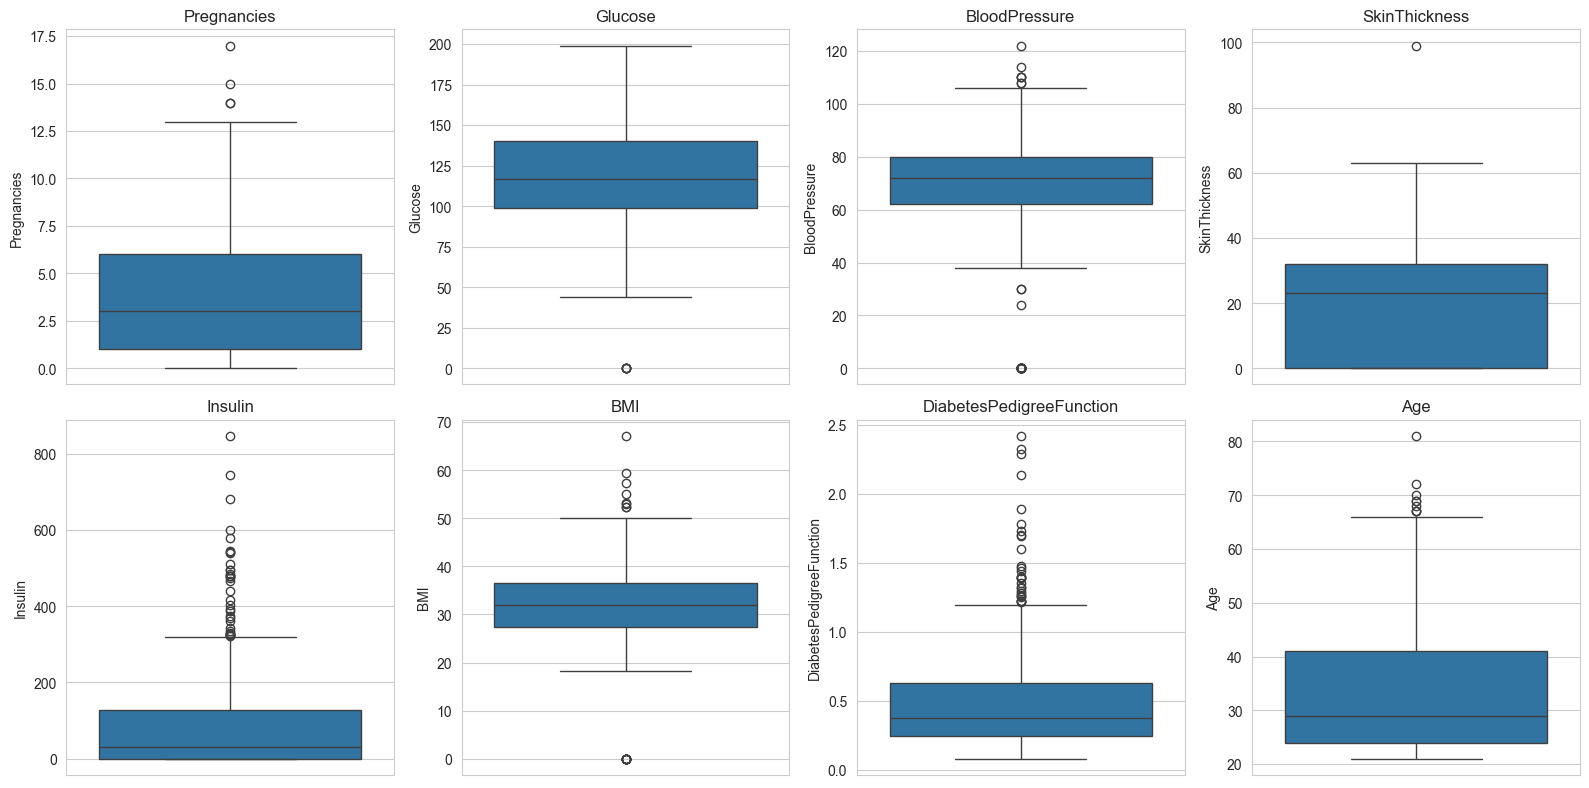

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), df.columns[:-1]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

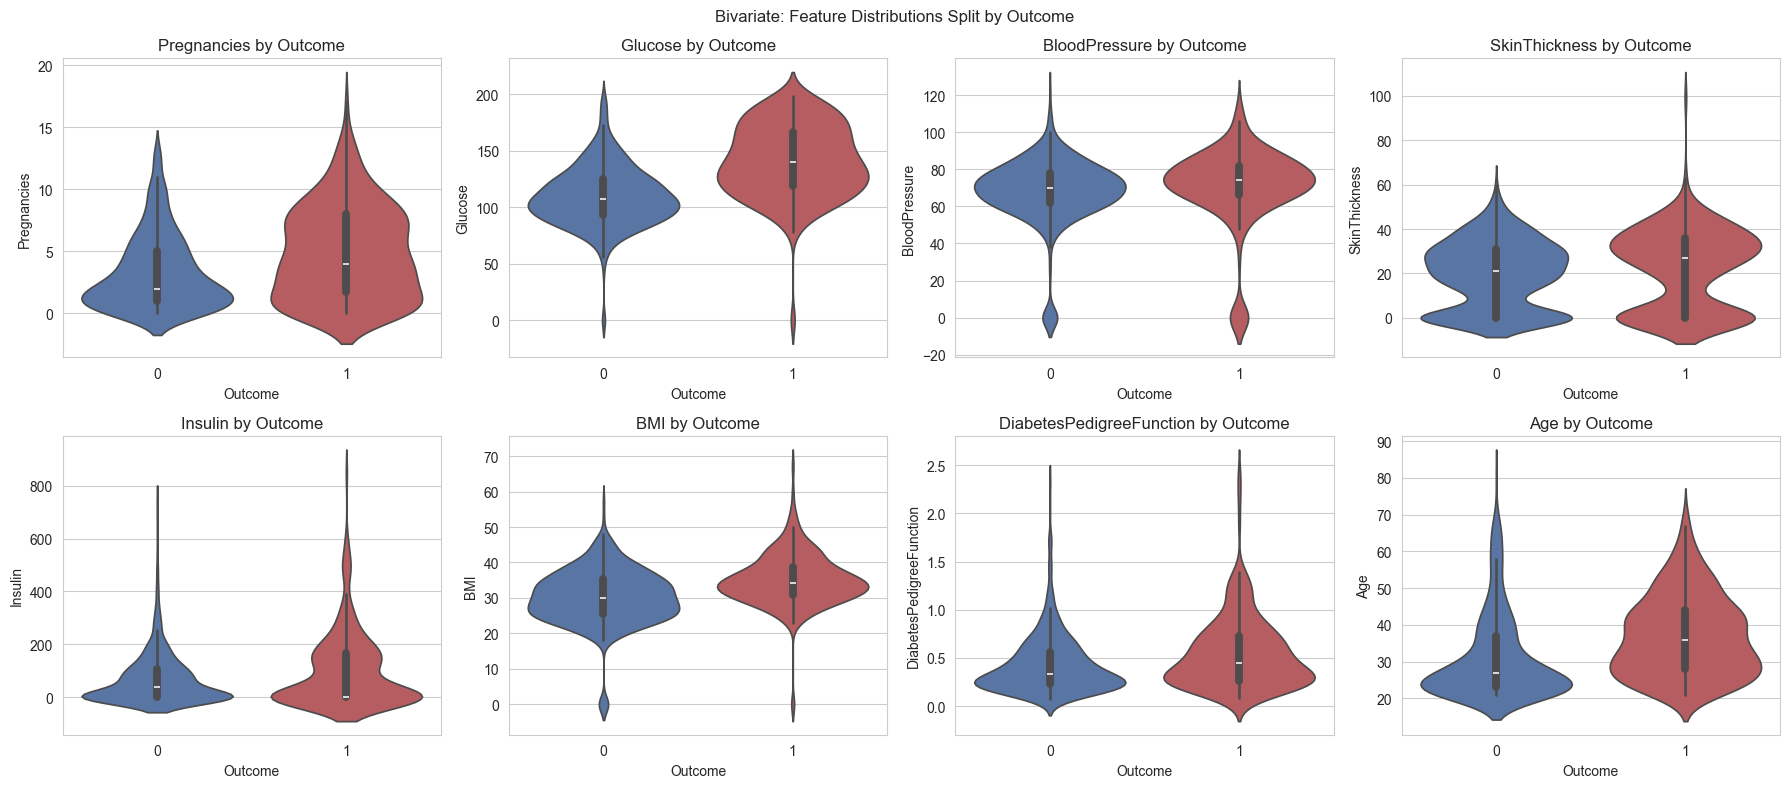

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), df.columns[:-1]):
    sns.violinplot(x='Outcome', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(f'{col} by Outcome')
plt.suptitle('Bivariate: Feature Distributions Split by Outcome')
plt.tight_layout()
plt.show()

## **Grouped statistics by diabetes outcome**

The numerical features are summarized separately for patients with and without diabetes to identify differences in central tendency and variability.

In [14]:
grouped_stats = df_clean.groupby("Outcome")[
    [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]
].agg(["mean", "median", "std"]).round(2)

grouped_stats

NameError: name 'df_clean' is not defined

## **Bivariate scatter plot analysis**

Scatter plots are used to examine relationships between important numerical features and identify whether feature combinations show different patterns for diabetic and non-diabetic observations.

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x="Glucose",
    y="BMI",
    hue="Outcome"
)

plt.title("Glucose vs BMI by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x="Age",
    y="Glucose",
    hue="Outcome"
)

plt.title("Age vs Glucose by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x="Pregnancies",
    y="Glucose",
    hue="Outcome"
)

plt.title("Pregnancies vs Glucose by Diabetes Outcome")
plt.xlabel("Pregnancies")
plt.ylabel("Glucose")
plt.show()

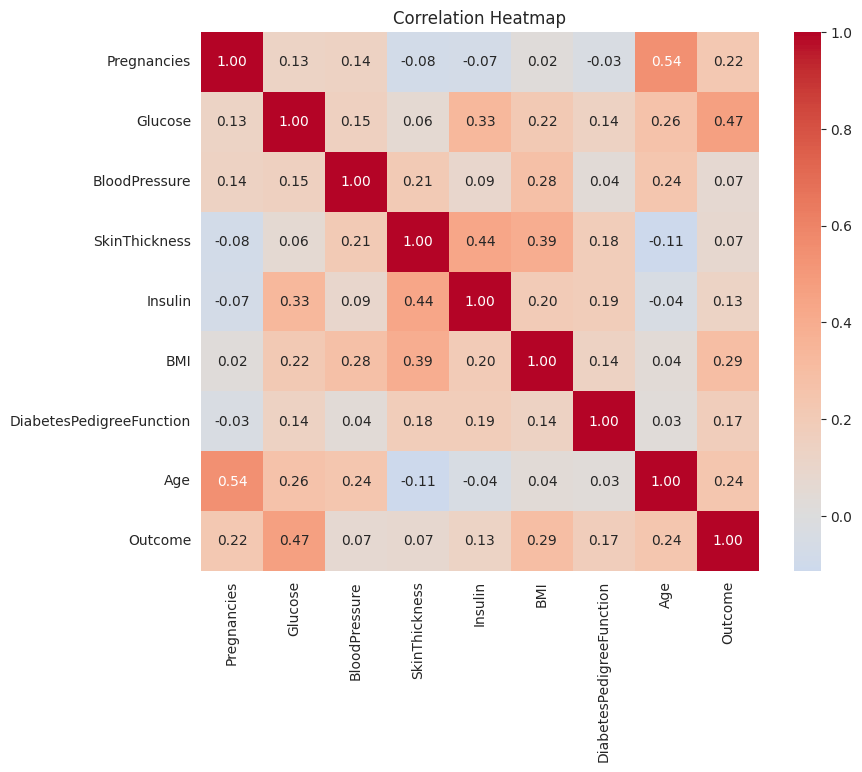

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# **Step 7 — Recode invalid zeros as missing (NaN)**

In [ ]:
df_clean = df.copy()
df_clean[cols_zero_invalid] = df_clean[cols_zero_invalid].replace(0, np.nan)
print(df_clean.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


# **Step 8 — Outlier analysis using the IQR method**

Outliers are identified using the Interquartile Range (IQR) method.

For each numerical feature:

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Outliers are identified for analysis but are not automatically removed because extreme clinical measurements may represent genuine observations.

In [ ]:
# IQR-based outlier analysis

outlier_summary = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

## **Step 8 — Train/test split (before imputing, to avoid data leakage)**

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


# **Step 9 — Impute missing values**

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer

median_cols = ['Glucose', 'BloodPressure', 'BMI']
knn_cols = ['SkinThickness', 'Insulin']

median_imp = SimpleImputer(strategy='median')
knn_imp = KNNImputer(n_neighbors=5)

X_train[median_cols] = median_imp.fit_transform(X_train[median_cols])
X_test[median_cols] = median_imp.transform(X_test[median_cols])

X_train[knn_cols] = knn_imp.fit_transform(X_train[knn_cols])
X_test[knn_cols] = knn_imp.transform(X_test[knn_cols])

# **Step 10 — Feature engineering**

In [ ]:
def engineer_features(data):
    data = data.copy()
    data['Age_Group'] = pd.cut(data['Age'], bins=[20,30,40,50,100],
                                labels=['21-30','31-40','41-50','51+'])
    data['BMI_Category'] = pd.cut(data['BMI'], bins=[0,18.5,25,30,100],
                                   labels=['Underweight','Normal','Overweight','Obese'])
    data['Glucose_Category'] = pd.cut(data['Glucose'], bins=[0,99,125,300],
                                       labels=['Normal','Prediabetic','Diabetic'])
    data['Glucose_BMI_Interaction'] = data['Glucose'] * data['BMI']
    data['Age_Pregnancies_Interaction'] = data['Age'] * data['Pregnancies']
    data['Log_Insulin'] = np.log1p(data['Insulin'])
    data['Log_DiabetesPedigreeFunction'] = np.log1p(data['DiabetesPedigreeFunction'])
    data = pd.get_dummies(data, columns=['Age_Group','BMI_Category','Glucose_Category'], drop_first=True)
    return data

X_train_fe = engineer_features(X_train)
X_test_fe = engineer_features(X_test)
X_train_fe, X_test_fe = X_train_fe.align(X_test_fe, join='left', axis=1, fill_value=0)
print(X_train_fe.shape, X_test_fe.shape)

(614, 20) (154, 20)


In [ ]:
# Save final feature column order for deployment

feature_columns = list(X_train_fe.columns)

joblib.dump(feature_columns, "feature_columns.joblib")

print("Feature columns saved successfully.")
print("Number of features:", len(feature_columns))
print("Feature columns:", feature_columns)

# **Step 11 — Feature scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_fe), columns=X_train_fe.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_fe), columns=X_test_fe.columns)

# **Step 12 — Train and compare 6 classical models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    'KNN': (KNeighborsClassifier(n_neighbors=7), True),
    'SVM': (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), True),
    'Decision Tree': (DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), False),
    'Random Forest': (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), False),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
}

results = {}
for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train_fe
    Xte = X_test_scaled if needs_scaling else X_test_fe
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    }

pd.DataFrame(results).T.sort_values('F1', ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.779221,0.700000,0.648148,0.673077,0.838889
SVM,0.779221,0.727273,0.592593,0.653061,0.821296
KNN,0.766234,0.695652,0.592593,0.640000,0.833426
Random Forest,0.740260,0.640000,0.592593,0.615385,0.831389
Logistic Regression,0.714286,0.604167,0.537037,0.568627,0.836667
Decision Tree,0.714286,0.604167,0.537037,0.568627,0.788796


# **Step 12A — Confusion matrices for all classical models**

Confusion matrices are used to compare the classification performance of the six classical machine learning models by showing true positives, true negatives, false positives and false negatives.

In [ ]:
for name, (model, needs_scaling) in models.items():

    Xte = X_test_scaled if needs_scaling else X_test_fe

    y_pred = model.predict(Xte)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# **Step 12B — Precision-Recall curve comparison**

Precision-Recall curves are used to evaluate the trade-off between precision and recall across different classification thresholds. This is particularly useful when evaluating the identification of positive diabetes cases.

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

plt.figure(figsize=(8, 6))

for name, (model, needs_scaling) in models.items():

    Xte = X_test_scaled if needs_scaling else X_test_fe

    y_proba = model.predict_proba(Xte)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_proba
    )

    ap = average_precision_score(
        y_test,
        y_proba
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Classical Models")
plt.legend()
plt.grid()
plt.show()

# **Step 13 — Build and train the MLP**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

tf.random.set_seed(RANDOM_STATE)

mlp = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = mlp.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200,
                   batch_size=32, callbacks=[early_stop], verbose=0)

y_proba_mlp = mlp.predict(X_test_scaled, verbose=0).ravel()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)
print('MLP F1:', f1_score(y_test, y_pred_mlp))

MLP F1: 0.6422018348623854


# **Step 13A — MLP learning curves**

Training and validation loss and accuracy are plotted to assess model convergence and identify potential overfitting or underfitting.

Loss

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

Accuracy

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# **Step 14 — Save the model and preprocessing objects**

In [ ]:
import joblib
mlp.save('final_mlp_model.keras')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(median_imp, 'median_imputer.joblib')
joblib.dump(knn_imp, 'knn_imputer.joblib')

['knn_imputer.joblib']

# **Step 15: Hyperparameter tuning with Optuna**

In [ ]:
!pip install optuna -q
import optuna
from tensorflow.keras.optimizers import Adam, RMSprop
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(
    X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units = [trial.suggest_categorical(f'units_l{i}', [8, 16, 32, 64]) for i in range(n_layers)]
    dropout_rate = trial.suggest_float('dropout', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])

    model = Sequential()
    model.add(Dense(units[0], activation='relu', input_shape=(X_tr_opt.shape[1],)))
    model.add(Dropout(dropout_rate))
    for u in units[1:]:
        model.add(Dense(u, activation='relu'))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    opt = Adam(learning_rate=learning_rate) if optimizer_name == 'adam' else RMSprop(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model.fit(X_tr_opt, y_tr_opt, validation_data=(X_val_opt, y_val_opt),
              epochs=100, batch_size=batch_size, callbacks=[es], verbose=0)

    val_pred = (model.predict(X_val_opt, verbose=0).ravel() >= 0.5).astype(int)
    return f1_score(y_val_opt, val_pred)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=25)
print('Best F1:', study.best_value)
print('Best params:', study.best_params)

Best F1: 0.7674418604651163
Best params: {'n_layers': 1, 'units_l0': 8, 'dropout': 0.17394178221021084, 'learning_rate': 0.00869299151113955, 'batch_size': 32, 'optimizer': 'rmsprop'}


# **Step 16 — Retrain final model with best params, evaluate on test set, save**

Final Tuned MLP -- Test Set Metrics: {'Accuracy': 0.7337662337662337, 'Precision': 0.6274509803921569, 'Recall': 0.5925925925925926, 'F1': 0.6095238095238096, 'ROC-AUC': np.float64(0.8305555555555556)}


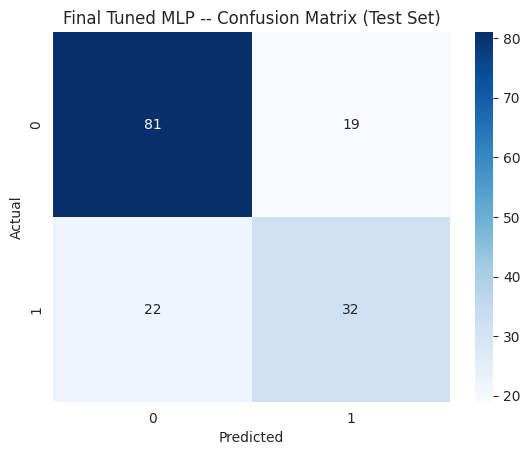

In [ ]:
bp = study.best_params
n_layers = bp['n_layers']
units = [bp[f'units_l{i}'] for i in range(n_layers)]
dropout_rate = bp['dropout']
learning_rate = bp['learning_rate']
batch_size = bp['batch_size']
optimizer_name = bp['optimizer']

final_model = Sequential()
final_model.add(Dense(units[0], activation='relu', input_shape=(X_train_scaled.shape[1],)))
final_model.add(Dropout(dropout_rate))
for u in units[1:]:
    final_model.add(Dense(u, activation='relu'))
    final_model.add(Dropout(dropout_rate))
final_model.add(Dense(1, activation='sigmoid'))

opt = Adam(learning_rate=learning_rate) if optimizer_name == 'adam' else RMSprop(learning_rate=learning_rate)
final_model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2, epochs=200, batch_size=batch_size,
    callbacks=[es], verbose=0
)
# Final MLP learning history
final_history_df = pd.DataFrame(
    final_history.history
)

final_history_df.head()

# Evaluate on the held-out test set -- the ONLY time it's touched for this model
final_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
final_pred = (final_proba >= 0.5).astype(int)

final_metrics = {
    'Accuracy': accuracy_score(y_test, final_pred),
    'Precision': precision_score(y_test, final_pred),
    'Recall': recall_score(y_test, final_pred),
    'F1': f1_score(y_test, final_pred),
    'ROC-AUC': roc_auc_score(y_test, final_proba),
}
print('Final Tuned MLP -- Test Set Metrics:', final_metrics)

cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final Tuned MLP -- Confusion Matrix (Test Set)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

Step 16A — Final MLP Loss Curve

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history_df["loss"],
    label="Training Loss"
)

plt.plot(
    final_history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Tuned MLP - Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

Step 16B — Final MLP Accuracy Curve



In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Tuned MLP - Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# **Step 17 — Overwrite the saved model with this tuned version**

In [ ]:
final_model.save('final_mlp_model.keras')
print('Saved final tuned model.')

Saved final tuned model.


# **Step 18 — Build the final consolidated comparison table**

In [ ]:
results['MLP (tuned, final)'] = final_metrics
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['Accuracy','Precision','Recall','F1','ROC-AUC']]
comparison_df = comparison_df.sort_values('F1', ascending=False)
comparison_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.7792,0.7000,0.6481,0.6731,0.8389
SVM,0.7792,0.7273,0.5926,0.6531,0.8213
KNN,0.7662,0.6957,0.5926,0.6400,0.8334
Random Forest,0.7403,0.6400,0.5926,0.6154,0.8314
"MLP (tuned, final)",0.7338,0.6275,0.5926,0.6095,0.8306
Logistic Regression,0.7143,0.6042,0.5370,0.5686,0.8367
Decision Tree,0.7143,0.6042,0.5370,0.5686,0.7888


# **Step 19 — ROC curves for all models, overlaid**

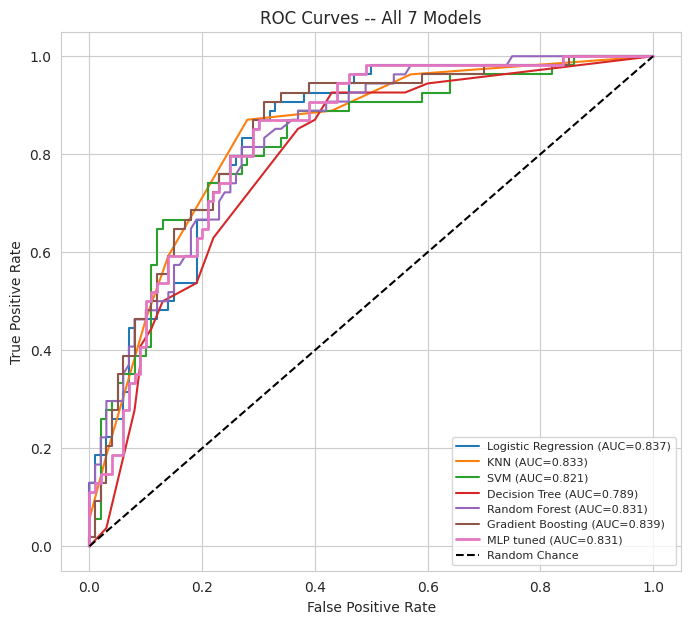

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,7))
for name, (model, needs_scaling) in models.items():
    Xte = X_test_scaled if needs_scaling else X_test_fe
    proba = model.predict_proba(Xte)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')

fpr, tpr, _ = roc_curve(y_test, final_proba)
plt.plot(fpr, tpr, label=f'MLP tuned (AUC={roc_auc_score(y_test, final_proba):.3f})', linewidth=2)
plt.plot([0,1],[0,1],'k--', label='Random Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves -- All 7 Models')
plt.legend(loc='lower right', fontsize=8)
plt.show()

In [ ]:
import os

deployment_files = [
    "final_mlp_model.keras",
    "scaler.joblib",
    "median_imputer.joblib",
    "knn_imputer.joblib",
    "feature_columns.joblib"
]

for file in deployment_files:
    print(f"{file}: {'✅ Found' if os.path.exists(file) else '❌ Missing'}")